---
title: "Exercises NFDI4Earth"
date: "2026-03-16"
---



In [32]:
# packages we need
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


# Exercises 1. part of the NFDI4Earth workshop 


## 1. Feature scale Transformations for explorative statistics

**Load one of the following data sets:**

Use the presented recipes for feature scale transformations for exploratory statistics (central tendency and dispersion) and visualize the the data in a meaningful manner (e.g. moments and/or sigma-invals, histogram, density plot, etc.)

#### 1.1. Runoff data from gauge Diepoldsau, Rhine River, Switzerland!
Data from the gauge Diepoldsau at the Rhine River in Switzerland, which is available at the website of the Federal Office for the Environment (FOEN) in Switzerland downloaded at https://www.gemstat.org

In [33]:
data = pd.read_csv("https://userpage.fu-berlin.de/soga/data/workshop_data/Suspsolids.csv",sep = ";", comment = '#')

# next we adress the variable types correctly:
data["DateTime"] = pd.to_datetime(data["DateTime"], format="mixed")
data["Discharge_m3_s"] = pd.to_numeric(data["Discharge_m3_s"])
data["Susp_solids_mg_L"] = data["Susp_solids_mg_L"].str.replace(",", "") # Remove ,
data["Susp_solids_mg_L"] = pd.to_numeric(data["Susp_solids_mg_L"])


# There are some missing values to remove:
data = data.dropna()

#### 1.2. Arctic sea ice data from the NSIDC (National Snow and Ice Data Center)
at the University of Colorado in Boulder hosts and provides monthly sea ice data for both hemispheres from November 1978 to the present.

In [34]:
N03 = pd.read_csv("https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_03_extent_v4.0.csv") # data for March
N09 = pd.read_csv("https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_09_extent_v4.0.csv") # data for September

### 1.3. German Meteorological Service DWD
The German Meteorological Service (DWD) provides a wide range of meteorological data. We prepared a data set, where you can analyse e.g. "Altitude", "Max_Air_temperature"and, "Mean_annual_Rainfall" for 599 stations in Germany.

Text(0, 0.5, 'Mean Annual Rainfall')

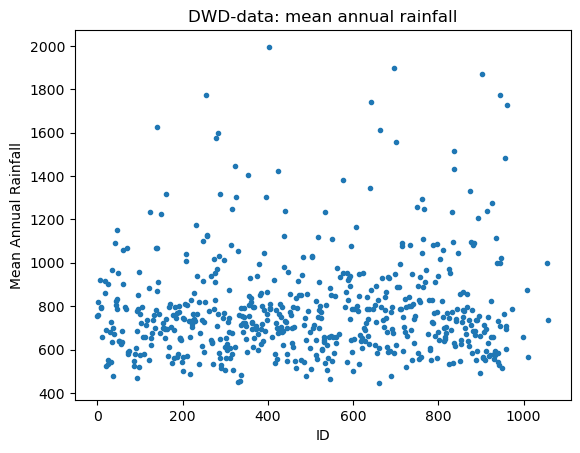

In [35]:
dwd = pd.read_csv("https://userpage.fu-berlin.de/soga/data/raw-data/DWD.csv", sep = ",")

# Exclude variables
dwd_data = dwd.drop(columns = ["ID", "DWD_ID", "STATION_NAME",  "PERIOD"])
plt.plot(dwd["ID"],dwd_data["MEAN_ANNUAL_RAINFALL"], ".")
plt.title("DWD-data: mean annual rainfall")
plt.xlabel("ID")
plt.ylabel("Mean Annual Rainfall")

## 2. Feature scale Transformations for CI's and NHST

#### 2.1. Runoff data from gauge Diepoldsau 
> Compare the mean and median of the runoff and suspension load data for seasons May-July and September - November. Apply appropriate transformations and perform a t-test to compare the means of two groups (e.g., high vs. low discharge). Estimate confidence regions for population means of both discharge seasons!

In [36]:
data_may = data[data["DateTime"].dt.month.isin([5,6,7])]
data_sep = data[data["DateTime"].dt.month.isin([9,10,11])]

nival_tss = data_may["Susp_solids_mg_L"]
nival_Q = data_may["Discharge_m3_s"]

pluvial_tss = data_sep["Susp_solids_mg_L"]
pluvial_Q = data_sep["Discharge_m3_s"]

# your code here #


#### 2.2. Arctic sea ice data from the NSIDC (National Snow and Ice Data Center)

> Estimate the change of ice cover extent for the period 1978 to 1990 and 2010 to today for the months of March and September. Apply appropriate transformations and perform a t-test to compare the means of two groups (e.g., 1978-1990 vs. 2010-today). Estimate confidence regions for population means and their differences for both periods!

In [37]:
N03area78 = N03.loc[N03["year"] <= 1990, " extent"]
N03area10 = N03.loc[N03["year"] >= 2010, " extent"]
N09area78 = N09.loc[N09["year"] <= 1990, " extent"]
N09area10 = N09.loc[N09["year"] >= 2010, " extent"]

# your code here #


### 2.3. German Meteorological Service DWD

> Compare variable  "Mean_annual_Rainfall" for the federal states of "Bayern" and "Niedersachsen". Apply appropriate transformations and perform a t-test to compare the means of two groups (e.g., high vs. low altitude). Estimate confidence regions for population means of both groups!

In [38]:
# Bayern
prec_Bay = dwd_data.loc[dwd_data["FEDERAL_STATE"] == "Bayern", "MEAN_ANNUAL_RAINFALL"]
alt_Bay = dwd_data.loc[dwd_data["FEDERAL_STATE"] == "Bayern", "ALTITUDE"]

# Niedersachsen
prec_Nie = dwd_data.loc[dwd_data["FEDERAL_STATE"] == "Niedersachsen", "MEAN_ANNUAL_RAINFALL"]
alt_Nie = dwd_data.loc[dwd_data["FEDERAL_STATE"] == "Niedersachsen", "ALTITUDE"]


# your code here #

## 3. Feature scale Transformations for robust correlation/ regression

> Apply an appropriate feature scale transformation for the data sets. Calculate the correlation between two (given) variables of the transformed data. Choose a regression model and perform it! 

#### 3.1. Runoff and suspension load data from gauge Diepoldsau, Rhine River, Switzerland!

> Estimate the dependency of the suspension from the discharge in snowmelt seasons and/or pluvial runoff season, by using an appropriate feature transformation and a suitable regression model.


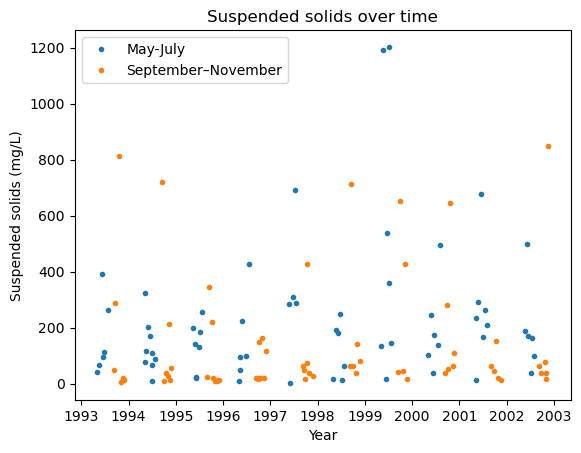

In [39]:
plt.plot(data_may["DateTime"], nival_tss,'.',label="May-July")
plt.title("Suspended solids over time")
plt.xlabel("Year")
plt.ylabel("Suspended solids (mg/L)")
plt.plot(data_sep["DateTime"], pluvial_tss,'.', label="September–November")

plt.legend()

# your code here #


#### 3.2. Arctic sea ice data from the NSIDC (National Snow and Ice Data Center)

> Examine the time dependency of the ice cover extent of either March or September data. Alternatively, you can test the limitations for the prediction of ice cover extent in September from March data.


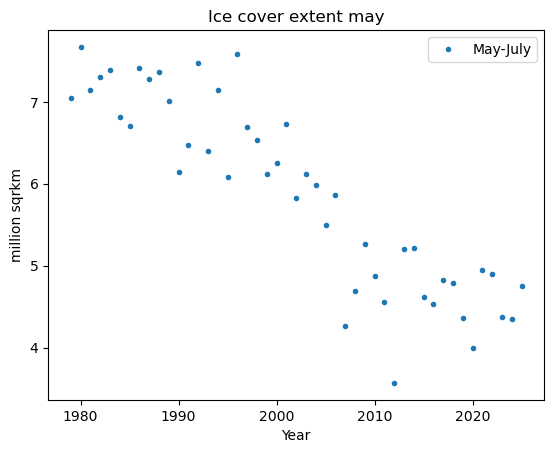

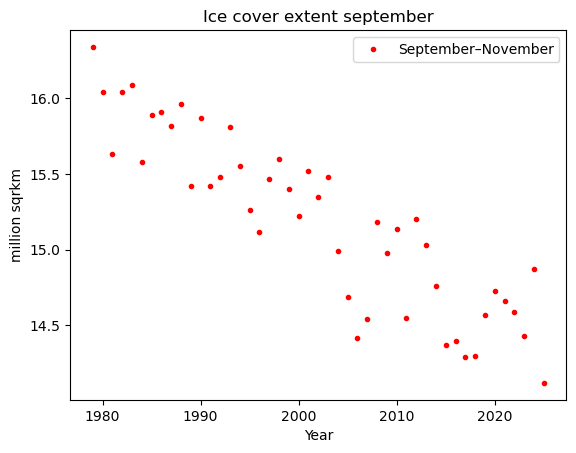

In [40]:
plt.plot(N09["year"], N09[" extent"],'.',label="May-July")
plt.title("Ice cover extent may")
plt.xlabel("Year")
plt.ylabel("million sqrkm")
plt.legend()
plt.show()

plt.plot(N03["year"], N03[" extent"],'.', label="September–November", color = "red")
plt.title("Ice cover extent september")
plt.xlabel("Year")
plt.ylabel("million sqrkm")
plt.legend()
plt.show()

# your code here #


#### 3.3. German Meteorological Service DWD

> Examine the influence of station altitude on mean annual rainfall in Germany using a suitable Feature Scale Transformation respective model!

Text(0.5, 0, 'Altitude')

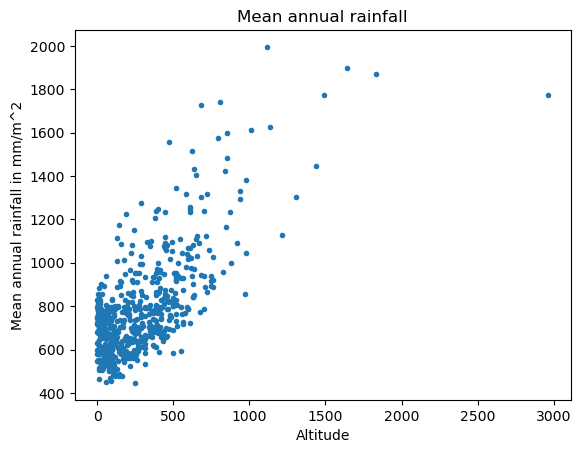

In [41]:

plt.plot(dwd_data["ALTITUDE"], dwd_data["MEAN_ANNUAL_RAINFALL"], ".")
plt.title("Mean annual rainfall")
plt.ylabel("Mean annual rainfall in mm/m^2")
plt.xlabel("Altitude")

# your code here #
